# Import libraries

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Load dataset

In [3]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

df = pd.read_csv("KDDTrain+.txt", names=columns)

# Convert label to binary (normal vs attack)

In [4]:
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Encode categorical columns

In [5]:
le = LabelEncoder()
for col in ["protocol_type", "service", "flag"]:
    df[col] = le.fit_transform(df[col])

# Split features and target

In [6]:
X = df.drop(["label", "difficulty"], axis=1)
y = df["label"]

# Train-test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model

In [8]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Save model

In [30]:
import joblib

joblib.dump(model, "ids_model.pkl")

print("Model saved successfully ✅")

Model saved successfully ✅


# Load model

In [9]:
import joblib

# Load model
model = joblib.load("ids_model.pkl")

print("Model loaded successfully ✅")

Model loaded successfully ✅


# Predictions

In [9]:
y_pred = model.predict(X_test)

# Evaluation

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9986505258979956

Confusion Matrix:
 [[13414     8]
 [   26 11747]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     13422
           1       1.00      1.00      1.00     11773

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



# demo

In [11]:
normal_sample = X_test[y_test == 1].iloc[0].values.reshape(1, -1)

prediction = model.predict(normal_sample)


if prediction[0] == 0:
    print("✅ Normal")
else:
    print("🚨 Attack Detected")

🚨 Attack Detected


c:\Users\chara\anaconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# Confusion Matrix

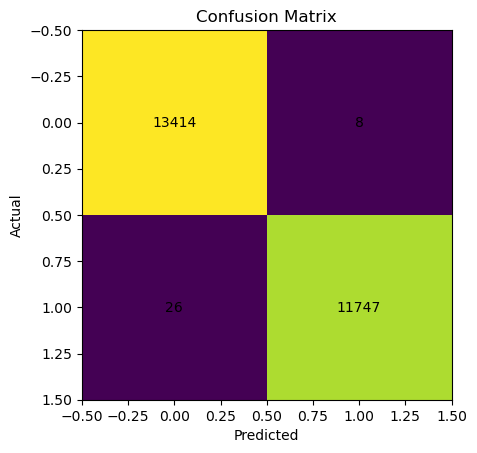

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

# Accuracy

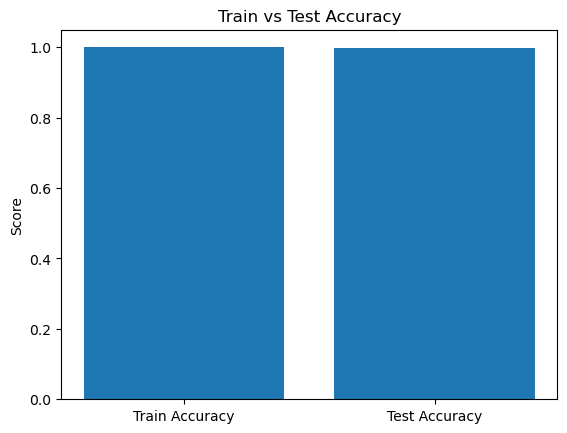

In [15]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

plt.bar(["Train Accuracy", "Test Accuracy"], [train_acc, test_acc])
plt.title("Train vs Test Accuracy")
plt.ylabel("Score")

plt.show()

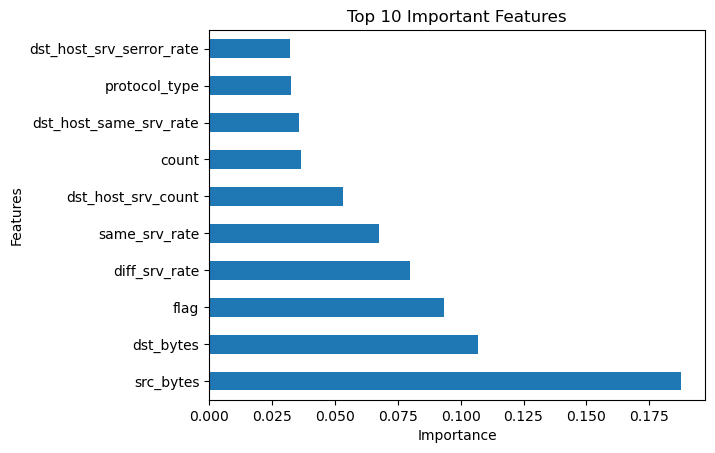

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names)

feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()